<a href="https://colab.research.google.com/github/paulaa7/Aprendizaje-automatico/blob/main/Chatbot-con-Deep-Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Asignatura**: Aprendizaje Automático

**Proyecto**: Creación de un Chatbot con Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 30 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Paula González García



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.  

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores

por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio Único: Desarrollo de un Chatbot Generativo (10 puntos)**

## 1. Contexto: Arquitectura Seq2Seq (Encoder-Decoder)

En este ejercicio desarrollaremos un chatbot capaz de mantener una conversación simple utilizando una arquitectura **Sequence-to-Sequence (Seq2Seq)** con redes neuronales recurrentes (LSTMs).

A diferencia de los chatbots basados en reglas o clasificación de intenciones, un modelo Seq2Seq aprende a generar la respuesta palabra por palabra basándose en la secuencia de entrada (la pregunta).

**El concepto:**
1. **Encoder:** Una LSTM procesa la frase del usuario y la comprime en un "vector de estado" (contexto).
2. **Decoder:** Otra LSTM toma ese vector de estado y genera la respuesta.

**Dataset:** Usaremos un corpus pequeño de pares Pregunta-Respuesta (suministrado en el código) para facilitar el entrenamiento en este entorno.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Pequeño dataset de ejemplo para la práctica (Pares Pregunta - Respuesta)
input_texts = [
    'Hola',
    '¿Cómo estás?',
    '¿Qué hora es?',
    'Adiós',
    '¿Quién eres?',
    '¿Qué haces?',
    'Buenos días',
    'Buenas noches',
    'Gracias',
    '¿Me ayudas?'
]

target_texts = [
    'Hola humano',
    'Estoy funcionando correctamente',
    'No tengo reloj',
    'Hasta la vista',
    'Soy un chatbot de IA',
    'Aprendiendo a hablar',
    'Buenos días, ¿en qué puedo servirte?',
    'Que descanses',
    'De nada',
    'Dime qué necesitas'
]

print(f"Número de muestras: {len(input_texts)}")
print(f"Ejemplo entrada: {input_texts[1]} -> Ejemplo salida: {target_texts[1]}")

Número de muestras: 10
Ejemplo entrada: ¿Cómo estás? -> Ejemplo salida: Estoy funcionando correctamente


## 2. Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesamiento de Texto:**
    * Tokenización de los textos de entrada y salida (a nivel de caracteres o palabras).
    * Creación de los diccionarios de vocabulario (token a índice e índice a token).
    * **Importante:** Para el Decoder, las secuencias objetivo deben tener tokens especiales de inicio (`<start>`) y fin (`<end>`) para controlar la generación.
    * Convertir las frases a secuencias de enteros (One-hot encoding o Padding sequences).

2.  **Construcción del Modelo (Training):**
    * Utilice la API funcional de Keras (`keras.Model`).
    * **Encoder:** Capa `Input` + Capa `Embedding` (opcional si usa one-hot) + Capa `LSTM`. Guarde los estados internos (`states`).
    * **Decoder:** Capa `Input` + Capa `LSTM` (inicializada con los estados del Encoder) + Capa `Dense` (con activación `softmax`).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Pérdida: `categorical_crossentropy`.
    * Entrene el modelo hasta que la pérdida converja (debido a los pocos datos, esto será rápido, pero vigile el overfitting).

4.  **Inferencia (Chat con el modelo):**
    * Construya una configuración de inferencia separada (Encoder Model y Decoder Model).
    * Implemente una función `decode_sequence(input_seq)` que:
        1.  Codifique la entrada.
        2.  Genere la salida token por token en un bucle, inyectando el token predicho como entrada para el siguiente paso temporal, hasta encontrar el token de fin o llegar al límite de longitud.
    * Pruebe el chatbot con las frases del conjunto de entrenamiento.

## 2.1. Preprocesamiento de Texto

En esta sección se realizará el preprocesamiento de los textos de entrada y salida para preparar los datos para el modelo Seq2Seq. Los pasos a seguir son:

1.  **Tokenización**: se tokenizarán las frases a nivel de caracteres. Esto significa que cada caracter único será un "token" en nuestro vocabulario.
2.  **Creación de Vocabularios**: se construirán diccionarios que mapeen cada token a un índice numérico (`char_to_idx`) y viceversa (`idx_to_char`) para las entradas y salidas.
3.  **Tokens Especiales**: para las secuencias de salida (respuestas del decoder), se añadirán tokens especiales de inicio (`<start>`) y fin (`<end>`). Estos son cruciales para indicar al decoder cuándo debe comenzar a generar una respuesta y cuándo debe detenerse.
4.  **Vectorización**: las frases se convertirán en secuencias de enteros utilizando los vocabularios creados. Para el entrenamiento, las secuencias objetivo se representarán en un formato one-hot encoding para que el modelo pueda predecir la probabilidad de cada carácter en la salida.

In [ ]:
# 1. Tokenización y Creación de Vocabulario

# Obtener todos los caracteres únicos de los textos de entrada
input_characters = sorted(list(set(''.join(input_texts))))
target_characters = sorted(list(set(''.join(target_texts))))

# Añadir tokens especiales para el target como elementos únicos en el vocabulario
target_characters = ['<start>', '<end>'] + target_characters

num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)

# Longitud máxima de la secuencia de salida: +2 para los tokens <start> y <end>
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts]) + 2

print(f'Número de tokens únicos del Encoder: {num_encoder_tokens}')
print(f'Número de tokens únicos del Decoder: {num_decoder_tokens}')
print(f'Longitud máxima de la secuencia de entrada: {max_encoder_seq_length}')
print(f'Longitud máxima de la secuencia de salida: {max_decoder_seq_length}')

# Crear mapeos de caracter a índice y de índice a caracter
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

print('\nDiccionario de entrada (ejemplo):', list(input_token_index.items())[:5])
print('Diccionario de salida (ejemplo):', list(target_token_index.items())[:5])

# 2. Vectorización de datos

# Arrays para almacenar los datos vectorizados
encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens),
    dtype='float32')
decoder_input_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens),
    dtype='float32')
decoder_target_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens),
    dtype='float32')

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.
    # Padding con espacios para el encoder
    for t_pad in range(len(input_text), max_encoder_seq_length):
        encoder_input_data[i, t_pad, input_token_index[' ']] = 1.

    # Preparar la secuencia de tokens para el decoder, incluyendo <start> y <end>
    # Tratar <start> y <end> como tokens individuales, no como cadenas a descomponer en caracteres
    decoder_sequence_tokens = ['<start>'] + list(target_text) + ['<end>']

    for t, token in enumerate(decoder_sequence_tokens):
        # decoder_input_data toma el token actual
        decoder_input_data[i, t, target_token_index[token]] = 1.
        # decoder_target_data es la misma que decoder_input_data pero desfasada en 1 paso de tiempo
        if t > 0:
            # el target para el paso t-1 es el token en el paso t
            decoder_target_data[i, t - 1, target_token_index[token]] = 1.

    # Padding para decoder_input_data
    for t_pad in range(len(decoder_sequence_tokens), max_decoder_seq_length):
        decoder_input_data[i, t_pad, target_token_index[' ']] = 1.

    # Padding para decoder_target_data
    # El último token de la secuencia target (antes del padding) ya se ha utilizado como target para el penúltimo paso
    # Los pasos restantes se rellenan con el token de espacio
    for t_pad in range(len(decoder_sequence_tokens) - 1, max_decoder_seq_length):
        decoder_target_data[i, t_pad, target_token_index[' ']] = 1.


print('\nDimensiones de los datos de entrada del Encoder:', encoder_input_data.shape)
print('Dimensiones de los datos de entrada del Decoder:', decoder_input_data.shape)
print('Dimensiones de los datos de salida del Decoder (Target):', decoder_target_data.shape)

Número de tokens únicos del Encoder: 29
Número de tokens únicos del Decoder: 39
Longitud máxima de la secuencia de entrada: 13
Longitud máxima de la secuencia de salida: 38

Diccionario de entrada (ejemplo): [(' ', 0), ('?', 1), ('A', 2), ('B', 3), ('C', 4)]
Diccionario de salida (ejemplo): [('<start>', 0), ('<end>', 1), (' ', 2), (',', 3), ('?', 4)]

Dimensiones de los datos de entrada del Encoder: (10, 13, 29)
Dimensiones de los datos de entrada del Decoder: (10, 38, 39)
Dimensiones de los datos de salida del Decoder (Target): (10, 38, 39)


## 2.2. Construcción del Modelo (Training)

En esta sección se construirá la arquitectura Seq2Seq (Encoder-Decoder) utilizando la API funcional de Keras. Este modelo será el que entrenaremos para aprender a mapear las secuencias de entrada a las secuencias de salida.

### Encoder

El Encoder es responsable de procesar la secuencia de entrada (la pregunta) y comprimir su información en un conjunto de vectores de estado. Estos vectores, conocidos como el "contexto", capturan la esencia de la entrada y se transferirán al Decoder.

*   **Input Layer**: define la forma de las secuencias de entrada del encoder. En nuestro caso, son secuencias one-hot de `max_encoder_seq_length` caracteres, donde cada carácter está representado por `num_encoder_tokens` dimensiones.
*   **LSTM Layer**: una capa LSTM es la elección natural para procesar secuencias. Tomará las entradas y devolverá su salida (opcionalmente) y, lo más importante, sus estados internos (estado oculto `h` y estado de celda `c`). Estos estados finales son los que capturan la "memoria" de la secuencia de entrada y se usarán para inicializar el Decoder.

### Decoder

El Decoder es responsable de generar la secuencia de salida (la respuesta) paso a paso, utilizando el contexto proporcionado por el Encoder. Se entrena para predecir el siguiente carácter en la secuencia de salida, dadas las entradas anteriores y el estado del Encoder.

*   **Input Layer**: define la forma de las secuencias de entrada del decoder. Estas también son secuencias one-hot, pero con `num_decoder_tokens` dimensiones para cada paso temporal (incluyendo los tokens especiales `<start>` y `<end>`).
*   **LSTM Layer**: otra capa LSTM, pero esta vez, se inicializa con los estados finales (`h` y `c`) del Encoder. Esto permite que el Decoder comience a generar la respuesta conociendo el contexto de la pregunta. También configuramos esta LSTM para que devuelva su secuencia de salida completa, ya que necesitamos una predicción para cada paso temporal de la secuencia de salida, y para que devuelva sus estados internos (aunque no los usaremos en el modelo de entrenamiento, son muy importantes para la inferencia).
*   **Dense Layer**: una capa `Dense` con activación `softmax` se aplica a la salida de la LSTM del Decoder en cada paso temporal. Es la encargada de predecir la probabilidad de cada token en el vocabulario del Decoder para ser el siguiente carácter en la secuencia de salida.

In [ ]:
# Hiperparámetros del modelo
latent_dim = 256  # Dimensionalidad del espacio latente de la LSTM

# Definición del Encoder
encoder_inputs = keras.Input(shape=(None, num_encoder_tokens))
encoder_lstm = keras.layers.LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
# Solo nos interesan los estados del encoder así que descarto las salidas
encoder_states = [state_h, state_c]

# Definición del Decoder
decoder_inputs = keras.Input(shape=(None, num_decoder_tokens))
decoder_lstm = keras.layers.LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = keras.layers.Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Unión del Encoder y Decoder en el modelo de entrenamiento
model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

print("Modelo Seq2Seq construido correctamente.")
model.summary()


Modelo Seq2Seq construido correctamente.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 29)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None, 39)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    292,864 │ input_layer[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    303,104 │ input_layer_1[0]… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 39)  │     10,023 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 605,991 (2.31 MB)

 Trainable params: 605,991 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

## 2.3. Compilación y Entrenamiento

Una vez que el modelo Seq2Seq ha sido definido, el siguiente paso es compilarlo y entrenarlo. La compilación prepara el modelo para el proceso de aprendizaje, especificando cómo se calculará la pérdida y cómo se optimizarán los pesos del modelo.

### Compilación del Modelo

*   **Optimizador**: utilizaré un optimizador como `rmsprop` o `adam`. Estos algoritmos son populares por su eficiencia en el ajuste de los pesos de la red neuronal durante el entrenamiento.
*   **Función de Pérdida**: dado que estamos trabajando con una tarea de clasificación multiclase (predicción de un token entre `num_decoder_tokens` posibles en cada paso temporal) y las etiquetas de salida están en formato one-hot encoding, la función de pérdida adecuada es `categorical_crossentropy`, la cual mide la diferencia entre la distribución de probabilidad predicha por el modelo y la distribución de probabilidad real (one-hot) de los tokens objetivo.

### Entrenamiento del Modelo

El entrenamiento se realizará alimentando el modelo con los datos de entrada del encoder (`encoder_input_data`), los datos de entrada del decoder (`decoder_input_data`) y los datos de salida esperados del decoder (`decoder_target_data`).

*   `batch_size`: define el número de muestras que se propagarán a través de la red antes de que se actualicen los pesos del modelo. Un tamaño de batch adecuado puede influir en la estabilidad y velocidad del entrenamiento.
*   `epochs`: representa el número de veces que el algoritmo de entrenamiento trabajará a través de todo el conjunto de datos de entrenamiento. Para nuestro pequeño dataset, se pueden requerir pocas épocas para alcanzar la convergencia, pero es importante monitorear el sobreajuste (overfitting).

Comenzando el entrenamiento del modelo...
Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 607ms/step - loss: 3.5721 - val_loss: 3.0464
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 2.8342 - val_loss: 1.5426
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 2.6133 - val_loss: 1.4809
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 2.1847 - val_loss: 1.6298
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 2.1340 - val_loss: 1.5424
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 2.2020 - val_loss: 1.4067
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 2.1370 - val_loss: 1.4520
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 2.0495 - val_loss: 1.4674
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 2.0294 - val_loss: 1.4400
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 2.0628 - val_loss: 1.7210
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 404ms/step - loss: 2.1370 - val_loss: 1.4735
Epoch 12/100
2/2 ━━━━

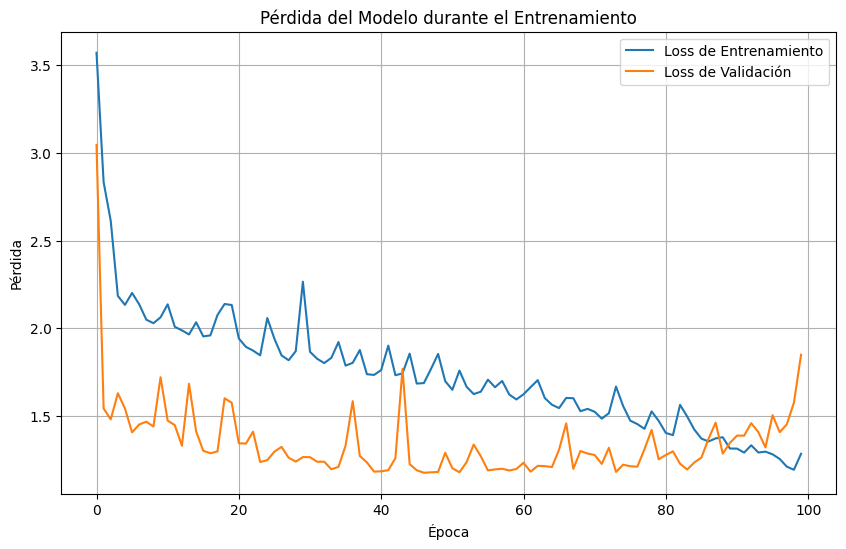

In [ ]:
# Compilar el modelo
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

# Entrenar el modelo
# Se utiliza un batch_size pequeño y pocas épocas debido al tamaño del dataset
# y para fines demostrativos. En un caso real, estos valores serían mayores.
epochs = 100
batch_size = 4

print("Comenzando el entrenamiento del modelo...")
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2, # Usar una fracción de los datos para validación
    verbose=1
)

print("Entrenamiento completado.")

# Gráfica de la pérdida para visualizar el progreso del entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Loss de Entrenamiento')
plt.plot(history.history['val_loss'], label='Loss de Validación')
plt.title('Pérdida del Modelo durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

Al analizar la gráfica de pérdida, se observa que el `Loss de Entrenamiento` disminuye consistentemente a lo largo de las épocas, lo cual indica que el modelo está aprendiendo de los datos de entrenamiento. Sin embargo, la `Loss de Validación` disminuye inicialmente, pero luego comienza a fluctuar e incluso a aumentar ligeramente hacia el final del entrenamiento. Esto sugiere que el modelo podría estar sobreajustándose a los datos de entrenamiento.

Dado el pequeño tamaño del dataset, el modelo aprende rápidamente los patrones específicos de las muestras de entrenamiento, pero puede tener dificultades para generalizar a datos no vistos (el conjunto de validación). Para resolver esto, en un escenario real se necesitaría un dataset mucho más grande o un monitoreo más estricto para detener el entrenamiento cuando la pérdida de validación deje de mejorar (early stopping).

## 2.4. Inferencia (Chat con el Modelo)

Para poder utilizar nuestro modelo Seq2Seq en un entorno de conversación en tiempo real, necesitamos configurar un modelo de inferencia separado. El modelo de entrenamiento está optimizado para aprender, pero no es ideal para generar respuestas token por token de manera interactiva. El proceso de inferencia se divide en dos partes:

### Encoder Model

El Encoder Model tomará una secuencia de entrada (la pregunta) y devolverá los estados finales de su LSTM (`state_h` y `state_c`). Estos estados representan el "contexto" de la pregunta y serán utilizados para inicializar el Decoder.

*   **Input Layer**: la misma que la del encoder de entrenamiento.
*   **Output**: los `state_h` y `state_c` del encoder LSTM.

### Decoder Model

El Decoder Model generará la secuencia de salida (la respuesta) un token a la vez. En cada paso tomará:

1.  El token generado previamente (inicialmente el token `<start>`).
2.  Los estados internos (`state_h` y `state_c`) del paso de tiempo anterior (inicialmente los del Encoder).

Devolverá la predicción del siguiente token y sus propios estados internos actualizados para el siguiente paso.

*   **Input Layers**: dos inputs principales: uno para la secuencia de entrada del decoder (el token actual que se va a procesar) y otros dos para los estados de entrada (`state_h` y `state_c`) del decoder.
*   **LSTM Layer**: la misma LSTM que usamos en el entrenamiento, pero ahora configurada para recibir estados iniciales y devolver sus propios estados actualizados, además de la secuencia de salida.
*   **Dense Layer**: la misma capa Dense con activación softmax para predecir el siguiente token.
*   **Output**: la distribución de probabilidad del siguiente token y los estados actualizados del decoder.

### Función `decode_sequence(input_seq)`

Esta función dirigirá el proceso de inferencia:

1.  **Codificar la entrada**: la `input_seq` se pasa al `encoder_model` para obtener los `states_value` iniciales.
2.  **Inicializar el decoder**: se crea una secuencia objetivo vacía y se inicializa con el token `<start>`.
3.  **Bucle de generación**: En cada iteración, el `decoder_model` predice el siguiente token basándose en el token actual de la secuencia objetivo y los `states_value`.
    *   El token con la mayor probabilidad se selecciona como el siguiente carácter.
    *   Si es el token `<end>` o se alcanza la longitud máxima de la secuencia, la generación se detiene.
    *   El token predicho se añade a la secuencia de salida generada.
    *   El token predicho se convierte en la entrada para el siguiente paso del decoder.
    *   Los `states_value` del decoder se actualizan con los estados generados en este paso.

In [ ]:
# 1. Modelos de Inferencia

# Encoder (para inferencia)
encoder_model = keras.Model(encoder_inputs, encoder_states)

# Decoder (para inferencia)
decoder_state_input_h = keras.Input(shape=(latent_dim,))
decoder_state_input_c = keras.Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = keras.Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states)

print("Modelos de inferencia (Encoder y Decoder) construidos.")

# 2. Función decode_sequence

def decode_sequence(input_seq):
    # Codificar la entrada para obtener el vector de estado inicial
    states_value = encoder_model.predict(input_seq)

    # Generar secuencia objetivo de un caracter, empezando con el token de inicio
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    target_seq[0, 0, target_token_index['<start>']] = 1.

    # Bucle para generar la secuencia de salida
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value)

        # Muestrear un token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += sampled_char

        # Comprobar si se cumple la condición de parada (token de fin o longitud máxima)
        if (sampled_char == '<end>' or
           len(decoded_sentence) > max_decoder_seq_length):
            stop_condition = True

        # Actualizar la secuencia objetivo (el token predicho se convierte en la nueva entrada)
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.

        # Actualizar estados
        states_value = [h, c]

    # Eliminar el token '<end>'
    if decoded_sentence.endswith('<end>') and len(decoded_sentence) > 5:
        decoded_sentence = decoded_sentence[:-5]

    return decoded_sentence.strip()

print("Función decode_sequence definida.")

# 3. Prueba del Chatbot

print("\n--- Probando el Chatbot ---")
for seq_index in range(len(input_texts)): # Iterar sobre todas las frases de entrenamiento
    input_seq = encoder_input_data[seq_index: seq_index + 1]
    decoded_sentence = decode_sequence(input_seq)
    print(f'Pregunta: {input_texts[seq_index]}')
    print(f'Respuesta: {decoded_sentence}')
    print('-')


Modelos de inferencia (Encoder y Decoder) construidos.
Función decode_sequence definida.

--- Probando el Chatbot ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Pregunta: Hola
Respuesta: Hooa  haaaaao
-
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/ste

## 3. Ampliación del Dataset

Como se observó en la inferencia anterior, con un dataset muy pequeño, el chatbot tiende a generar respuestas repetitivas o incoherentes. Para mejorar su capacidad de respuesta, es fundamental ampliar y diversificar el conjunto de datos de entrenamiento. Estrategias utilizadas para enriquecer el dataset:

1.  **Aumento de la Cantidad de Pares Pregunta-Respuesta**: añadir más ejemplos de conversaciones ayuda al modelo a aprender una gama más amplia de patrones lingüísticos y a comprender mejor el contexto.
2.  **Múltiples Respuestas para una Misma Entrada**: para hacer que el chatbot sea menos predecible y más natural, se pueden asociar varias respuestas posibles a una misma pregunta. Esto introduce una variabilidad en las respuestas del modelo, simulando una conversación más humana. Aunque el modelo Seq2Seq básico no maneja esto directamente en la inferencia determinista (`argmax`), en el entrenamiento ayuda a suavizar las distribuciones de probabilidad y, con técnicas de muestreo, podría generar respuestas diferentes.
3.  **Variación de Entradas para una Misma Respuesta**: diferentes formas de preguntar lo mismo deberían llevar a una respuesta similar. Incluir sinónimos, diferentes estructuras de frases o preguntas relacionadas para una misma respuesta ayuda al modelo a generalizar mejor.
4.  **Temáticas Específicas**: enfocar el dataset en uno o varios temas de interés (en este caso, preguntas generales) permite al chatbot desarrollar un conocimiento más profundo dentro de esos dominios. También he añadido algunas preguntas que pueden parecer triviales pero podrían servir para probar la personalidad y habilidad del chatbot.

El dataset a continuación incorpora estas ideas, con un número significativamente mayor de pares y variaciones en preguntas y respuestas.




**Importante:** para probar el chatbot con este dataset ampliado, hay que ejecutar de nuevo todas las celdas desde la sección 2.1 ('Preprocesamiento de Texto') hasta la sección 2.4 ('Inferencia (Chat con el Modelo)'), para actualizar los vocabularios, las dimensiones del modelo y el entrenamiento.

In [ ]:
# Ampliación del dataset

input_texts = [
    'Hola',
    'Hola, ¿cómo estás?',
    'Buenos días',
    'Buenas tardes',
    'Buenas noches',
    '¿Cómo estás?',
    '¿Qué tal?',
    '¿Todo bien?',
    '¿Qué hora es?',
    'No tengo reloj',
    'Dime la hora',
    'Adiós',
    'Hasta luego',
    'Nos vemos',
    '¿Quién eres?',
    'Preséntate',
    '¿Cuál es tu nombre?',
    '¿Qué haces?',
    'A qué te dedicas',
    'Qué puedes hacer',
    'Gracias',
    'Muchas gracias',
    'Te lo agradezco',
    '¿Me ayudas?',
    'Necesito ayuda',
    'Ayúdame por favor',
    '¿Tienes sentimientos?',
    '¿Puedes pensar?',
    '¿Eres inteligente?',
    '¿De dónde vienes?',
    '¿Quién te creó?',
    'Háblame de ti',
    '¿Qué es un chatbot?',
    'Explícame qué eres',
    'Cuéntame un chiste',
    'Hazme reír',
    '¿Cuál es el sentido de la vida?',
    'Quién soy',
    '¿Qué es la inteligencia artificial?',
    'Definición de IA',
    '¿Tienes hambre?',
    '¿Estás cansado?',
    '¿Puedes aprender?',
    'Aprende de mí'
]

target_texts = [
    'Hola, ¿en qué puedo ayudarte?',
    'Estoy bien, gracias por preguntar.',
    'Buenos días, espero que tengas un excelente día.',
    'Buenas tardes. ¿Necesitas algo?',
    'Buenas noches, que tengas un buen descanso.',
    'Estoy funcionando perfectamente, gracias.',
    'Muy bien, listo para asistirte.',
    'Todo en orden, ¿y tú?',
    'No tengo acceso a la hora actual. Soy una IA.',
    'Como soy un programa, no tengo reloj físico.',
    'Lo siento, no puedo decirte la hora.',
    'Adiós, espero verte pronto.',
    'Hasta luego, que tengas un buen día.',
    'Claro, nos vemos. ¡Cuídate!',
    'Soy un asistente virtual, un programa de computadora.',
    'Mi nombre es Chatbot, y estoy aquí para ayudarte.',
    'Puedes llamarme Chatbot.',
    'Estoy aquí para conversar y ayudarte con tus preguntas.',
    'Mi propósito es procesar información y generar respuestas.',
    'Puedo responder preguntas, ofrecer información y charlar.',
    'De nada, me alegro de poder ayudarte.',
    'Es un placer servirte.',
    'No hay de qué.',
    'Claro, dime qué necesitas y haré lo posible.',
    'Estoy a tu disposición, ¿cuál es tu consulta?',
    'Con gusto te ayudaré, ¿en qué piensas?',
    'Como IA, no tengo sentimientos ni emociones.',
    'No, no siento, solo proceso información.',
    'Puedo procesar información, pero no tengo conciencia propia.',
    'Soy un programa de computadora, creado para interactuar contigo.',
    'Fui diseñado por mis desarrolladores.',
    'Soy un algoritmo, sin origen físico ni creador único.',
    'Soy un chatbot, un programa diseñado para simular una conversación humana.',
    'Soy una inteligencia artificial conversacional.',
    'Lo siento, no soy muy bueno con los chistes.',
    '¿Qué le dice un semáforo a otro? No me mires que me estoy cambiando.',
    'Esa es una pregunta profunda que la humanidad sigue explorando.',
    'Eres un ser humano, único e irremplazable.',
    'La IA es la simulación de procesos de inteligencia humana por máquinas.',
    'Es la capacidad de las máquinas para realizar tareas que requieren inteligencia humana.',
    'No tengo cuerpo, así que no tengo hambre ni cansancio.',
    'Como programa, no me canso.',
    'Sí, puedo aprender y mejorar con los datos que se me proporcionan.',
    'Cada interacción es una oportunidad para refinar mis respuestas.'
]

print(f"Número de muestras con el dataset ampliado: {len(input_texts)}")
print(f"Ejemplo entrada: {input_texts[30]} -> Ejemplo salida: {target_texts[30]}")

Número de muestras con el dataset ampliado: 44
Ejemplo entrada: ¿Quién te creó? -> Ejemplo salida: Fui diseñado por mis desarrolladores.


---

# **Conclusiones y Limitaciones**
### 1. ¿Qué sucede si introduce una frase que no estaba en el set de entrenamiento (ej: "Hola amigo")?

Al introducir una frase que no está en el conjunto de entrenamiento, el modelo Seq2Seq basado en caracteres intentará generar una respuesta utilizando los caracteres que conoce. Los resultados pueden variar entre:

*   **Respuestas incoherentes o sin sentido**: es el resultado más común. El modelo no ha visto la secuencia de caracteres ni el patrón asociado a esa entrada y, por lo tanto, no puede mapearla a una respuesta significativa.
*   **Respuestas genéricas**: podría generar respuestas que ha aprendido a asociar con patrones de inicio de conversación, pero sin coherencia con la pregunta real.
*   **Repetición de caracteres**: en ocasiones, el modelo podría caer en bucles de repetición de caracteres o secuencias cortas.
*   **Vocabulario limitado**: al ser un modelo a nivel de caracter, puede generar cualquier secuencia de caracteres que haya visto en el entrenamiento, pero la combinación de estos caracteres para formar palabras desconocidas o contextos nuevos es muy limitada. Además, la capa `Dense` del decoder solo predice entre los caracteres del `target_characters`.

El problema se agravaría si la frase contuviese caracteres que no están en el vocabulario del encoder, ya que estos caracteres no serían reconocidos en absoluto, generando entradas con información nula para esos tokens.

### 2. ¿Cuáles son las limitaciones de las redes recurrentes (LSTMs) frente a arquitecturas modernas como los Transformers (p.ej. BERT o GPT) para esta tarea?

Aunque las LSTMs (y otras RNNs) fueron un avance importante en el procesamiento de secuencias, tienen limitaciones importantes en comparación con arquitecturas modernas basadas en Transformers:

*   **Problema de la Dependencia a Largo Plazo**: aunque las LSTMs están diseñadas para mitigar el problema de los gradientes que desaparecen de las RNNs tradicionales, siguen teniendo dificultades para capturar dependencias a muy largo plazo en secuencias muy largas. Los Transformers, con sus mecanismos de autoatención (self-attention), pueden procesar todas las palabras de una secuencia en paralelo y calcular la relevancia de cada palabra con respecto a todas las demás, sin importar la distancia, lo que les permite capturar dependencias a largo plazo de manera mucho más eficiente.

*   **Paralelización y Velocidad de Entrenamiento**: las LSTMs procesan las secuencias de forma secuencial (token a token). Esto significa que no pueden aprovechar completamente la paralelización que ofrecen las GPUs. Los Transformers, al calcular la atención de todos los tokens simultáneamente, pueden procesar las secuencias en paralelo, lo que resulta en tiempos de entrenamiento mucho más rápidos, especialmente con grandes datasets.

*   **Capacidad de Modelado Contextual**: los Transformers, a través de sus múltiples capas de atención, pueden aprender representaciones contextuales más ricas y matizadas de las palabras. Un mismo token puede tener diferentes representaciones dependiendo de su contexto en la frase, algo que las LSTMs modelan de forma menos explícita.

*   **Pre-entrenamiento y Transfer Learning**: modelos como BERT y GPT-3 son entrenados en enormes cantidades de texto no etiquetado (pre-entrenamiento) y luego afinados para tareas específicas (fine-tuning). Esta capacidad de Transfer Learning es muy poderosa, permitiendo alcanzar un rendimiento superior con menos datos específicos de la tarea. Las LSTMs no tienen un paradigma de pre-entrenamiento tan robusto.

*   **Longitud de Secuencia**: los Transformers manejan secuencias mucho más largas de manera efectiva, lo que es vital para tareas como el resumen de documentos o la traducción de textos extensos. Las LSTMs tienden a empeorar su rendimiento con secuencias muy largas debido a la acumulación de información en sus estados.

En conclusión, mientras que los modelos Seq2Seq con LSTMs son una base fundamental para entender el procesamiento de lenguaje natural generativo, los Transformers ofrecen ventajas en términos de escalabilidad, eficiencia, capacidad de modelado y rendimiento en la mayoría de las tareas modernas de PNL.